In [1]:
pip install Faker

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [3]:
from faker import Faker

In [4]:
import random

In [6]:
# creamos una instancia faker
fake = Faker("es_MX")

In [29]:
datos = []
for i in range(100):
    datos.append({
        "Id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(
            ["Tiktok", "Instagram", "Youtube"]
        )
    })

In [30]:
df = pd.DataFrame(datos)
df.head()

,Id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Inés Alvarado Molina,xvargas@example.com,53,14606,Instagram
1,2,Diana Abigail Armendáriz Flores,noelia27@example.com,45,43153,Tiktok
2,3,Srita. Ariadna Segura,humbertorendon@example.com,21,12249,Tiktok
3,4,Leonel Saucedo Merino,qbahena@example.org,35,27204,Youtube
4,5,Srita. Lucía Guillen,xvallejo@example.com,65,29865,Tiktok


In [31]:
# exploracion del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Id_usuario  100 non-null    int64
 1   nombre      100 non-null    str  
 2   correo      100 non-null    str  
 3   edad        100 non-null    int64
 4   seguidores  100 non-null    int64
 5   plataforma  100 non-null    str  
dtypes: int64(3), str(3)
memory usage: 4.8 KB


In [32]:
# estadistica descriptiva
df.describe(include="all")

,Id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.000000,100.000000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,Inés Alvarado Molina,xvargas@example.com,NaN,NaN,Instagram
freq,NaN,1,1,NaN,NaN,40
mean,50.500000,NaN,NaN,42.450000,28175.570000,NaN
std,29.011492,NaN,NaN,14.524361,14564.481048,NaN
min,1.000000,NaN,NaN,18.000000,735.000000,NaN
25%,25.750000,NaN,NaN,30.750000,14431.000000,NaN
50%,50.500000,NaN,NaN,42.000000,29516.500000,NaN
75%,75.250000,NaN,NaN,56.000000,41693.500000,NaN


In [33]:
# Importar librerias para graficar 
import seaborn as sns
import matplotlib.pyplot as plt

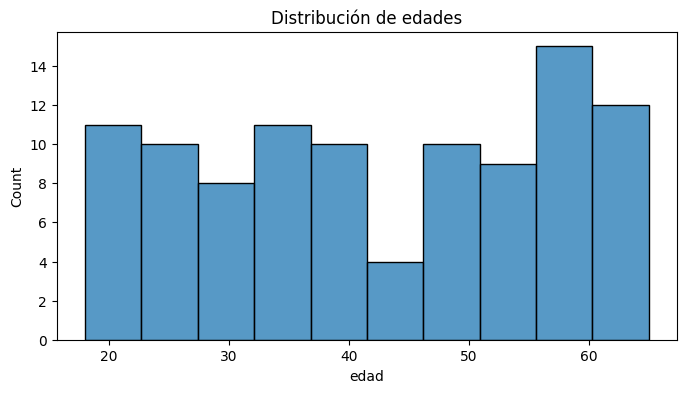

In [34]:
# Distribucion de edades
plt .figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribución de edades")
plt.show()

In [35]:
df_sucio = df.copy()

In [36]:
# le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"nombre"] = None

In [37]:
df_sucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Id_usuario  100 non-null    int64
 1   nombre      95 non-null     str  
 2   correo      100 non-null    str  
 3   edad        100 non-null    int64
 4   seguidores  100 non-null    int64
 5   plataforma  100 non-null    str  
dtypes: int64(3), str(3)
memory usage: 4.8 KB


In [38]:
# Edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"] = -10

In [39]:
df_sucio.describe()["edad"]

count    100.000000
mean      39.950000
std       18.178339
min      -10.000000
25%       28.000000
50%       39.500000
75%       56.000000
max       65.000000
Name: edad, dtype: float64

In [40]:
# Seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"seguidores"] = 5000000

In [41]:
df_sucio.describe()["seguidores"]

count    1.000000e+02
mean     2.768682e+05
std      1.089114e+06
min      7.350000e+02
25%      1.549300e+04
50%      3.078500e+04
75%      4.246750e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [42]:
# Correos invalidos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"correo"] = "correo_invalido"

In [43]:
df_sucio.describe(include=["str", "object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Inés Alvarado Molina,correo_invalido,Instagram
freq,1,5,40


In [44]:
df_sucio.isnull().sum()

Id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [45]:
# estadisticas
df_sucio.describe(include="all")

,Id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,95,100,100.000000,1.000000e+02,100
unique,NaN,95,96,NaN,NaN,3
top,NaN,Inés Alvarado Molina,correo_invalido,NaN,NaN,Instagram
freq,NaN,1,5,NaN,NaN,40
mean,50.500000,NaN,NaN,39.950000,2.768682e+05,NaN
std,29.011492,NaN,NaN,18.178339,1.089114e+06,NaN
min,1.000000,NaN,NaN,-10.000000,7.350000e+02,NaN
25%,25.750000,NaN,NaN,28.000000,1.549300e+04,NaN
50%,50.500000,NaN,NaN,39.500000,3.078500e+04,NaN
75%,75.250000,NaN,NaN,56.000000,4.246750e+04,NaN


In [46]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)